In [8]:
# Run this in your first cell
!pip install requests beautifulsoup4 pandas

In [15]:
import pandas as pd
import os

# Check if the file exists in the Colab environment
file_path = '/content/austinHousingData.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print("✅ Success! Dataset loaded from your local upload.")
    print(f"Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")
    display(df.head())
else:
    print("‼️ File not found. Did you upload 'austinHousingData.csv' to the folder icon on the left?")

✅ Success! Dataset loaded from your local upload.
Dataset contains 15171 rows and 47 columns.


,zpid,city,streetAddress,zipcode,description,latitude,longitude,propertyTaxRate,garageSpaces,hasAssociation,...,numOfMiddleSchools,numOfHighSchools,avgSchoolDistance,avgSchoolRating,avgSchoolSize,MedianStudentsPerTeacher,numOfBathrooms,numOfBedrooms,numOfStories,homeImage
0,111373431,pflugerville,14424 Lake Victor Dr,78660,"14424 Lake Victor Dr, Pflugerville, TX 78660 i...",30.430632,-97.663078,1.98,2,True,...,1,1,1.266667,2.666667,1063,14,3.0,4,2,111373431_ffce26843283d3365c11d81b8e6bdc6f-p_f...
1,120900430,pflugerville,1104 Strickling Dr,78660,Absolutely GORGEOUS 4 Bedroom home with 2 full...,30.432673,-97.661697,1.98,2,True,...,1,1,1.400000,2.666667,1063,14,2.0,4,1,120900430_8255c127be8dcf0a1a18b7563d987088-p_f...
2,2084491383,pflugerville,1408 Fort Dessau Rd,78660,Under construction - estimated completion in A...,30.409748,-97.639771,1.98,0,True,...,1,1,1.200000,3.000000,1108,14,2.0,3,1,2084491383_a2ad649e1a7a098111dcea084a11c855-p_...
3,120901374,pflugerville,1025 Strickling Dr,78660,Absolutely darling one story home in charming ...,30.432112,-97.661659,1.98,2,True,...,1,1,1.400000,2.666667,1063,14,2.0,3,1,120901374_b469367a619da85b1f5ceb69b675d88e-p_f...
4,60134862,pflugerville,15005 Donna Jane Loop,78660,Brimming with appeal & warm livability! Sleek ...,30.437368,-97.656860,1.98,0,True,...,1,1,1.133333,4.000000,1223,14,3.0,3,2,60134862_b1a48a3df3f111e005bb913873e98ce2-p_f.jpg


In [16]:
# 1. Drop columns that don't help with price prediction (like image links or descriptions)
cols_to_drop = ['homeImage', 'description', 'streetAddress', 'zpid']
df_clean = df.drop(columns=cols_to_drop)

# 2. Check for Missing Values
print("Missing values per column:")
print(df_clean.isnull().sum().sort_values(ascending=False).head(5))

# 3. Fill missing values (if any) or drop rows with NAs
df_clean = df_clean.dropna()

# 4. Filter for "Single Family" homes only to make our analysis more focused
# This is a 'strategic' decision an advanced analyst makes
if 'homeType' in df_clean.columns:
    df_clean = df_clean[df_clean['homeType'] == 'Single Family']

print(f"\nCleaned Data Shape: {df_clean.shape}")

Missing values per column:
city               0
zipcode            0
latitude           0
longitude          0
propertyTaxRate    0
dtype: int64

Cleaned Data Shape: (14241, 43)


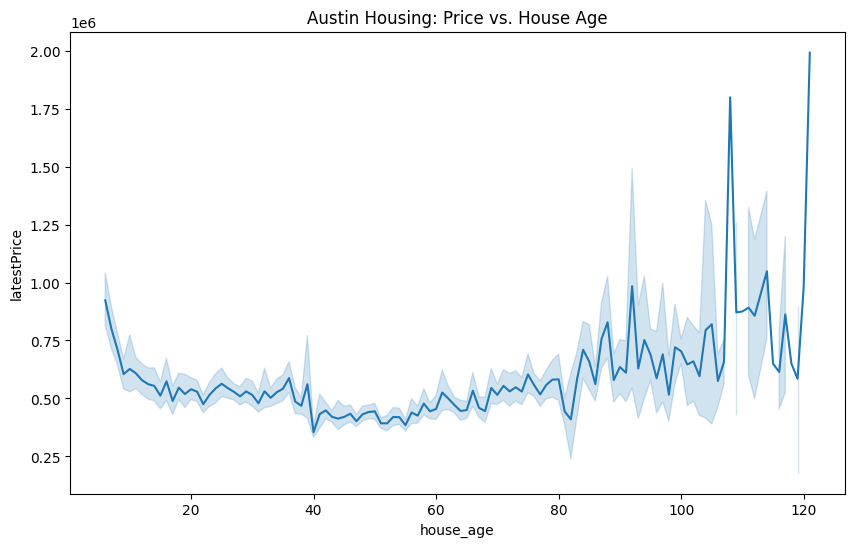

In [17]:
# Calculate Price per Square Foot
df_clean['price_per_sqft'] = df_clean['latestPrice'] / df_clean['livingAreaSqFt']

# Calculate Age of the home (Assume current year is 2026)
df_clean['house_age'] = 2026 - df_clean['yearBuilt']

# Let's see how Age affects Price
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.lineplot(data=df_clean, x='house_age', y='latestPrice')
plt.title('Austin Housing: Price vs. House Age')
plt.show()

In [18]:
df_clean['price_per_sqft'].mean()

np.float64(236.84531727426483)

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Define our Features (X) and our Target (y)
# We choose features that likely impact price
features = ['livingAreaSqFt', 'garageSpaces', 'avgSchoolRating', 'house_age', 'propertyTaxRate']
X = df_clean[features]
y = df_clean['latestPrice']

# 2. Split the data: 80% for training the "brain", 20% for testing it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
print("Training the model... (this may take a few seconds)")
model.fit(X_train, y_train)

# 4. Make Predictions and Evaluate
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"\n✅ Model Training Complete!")
print(f"Average Prediction Error (MAE): ${mae:,.2f}")
print(f"Model Accuracy (R2 Score): {r2:.2f}")

Training the model... (this may take a few seconds)

✅ Model Training Complete!
Average Prediction Error (MAE): $130,538.31
Model Accuracy (R2 Score): 0.61


In [22]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Using the CORRECT column names found in your dataframe
# We use 'numOfBathrooms' and 'numOfBedrooms' instead of 'bathrooms'/'bedrooms'
advanced_features = [
    'livingAreaSqFt', 'numOfBathrooms', 'numOfBedrooms', 'garageSpaces',
    'avgSchoolRating', 'house_age', 'latitude', 'longitude', 'propertyTaxRate'
]

# Ensure we are only using rows where these features exist
X_adv = df_clean[advanced_features]

# 2. Log Transform the Target (Advanced trick to handle price outliers)
y_adv = np.log1p(df_clean['latestPrice'])

# 3. Split
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_adv, y_adv, test_size=0.2, random_state=42)

# 4. Train the Model
print("Training the Optimized Model... 🚀")
adv_model = RandomForestRegressor(n_estimators=200, max_features='sqrt', random_state=42)
adv_model.fit(X_train_a, y_train_a)

# 5. Predict and Reverse the Log to get actual dollars
log_preds = adv_model.predict(X_test_a)
predictions_final = np.expm1(log_preds)
y_test_final = np.expm1(y_test_a)

# 6. Final Metrics
new_mae = mean_absolute_error(y_test_final, predictions_final)
new_r2 = r2_score(y_test_final, predictions_final)

print(f"\n✅ SUCCESS!")
print(f"Optimized MAE: ${new_mae:,.2f}")
print(f"Optimized R2 Score: {new_r2:.2f}")

Training the Optimized Model... 🚀

✅ SUCCESS!
Optimized MAE: $99,844.31
Optimized R2 Score: 0.71


/tmp/ipykernel_3097/2330806569.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


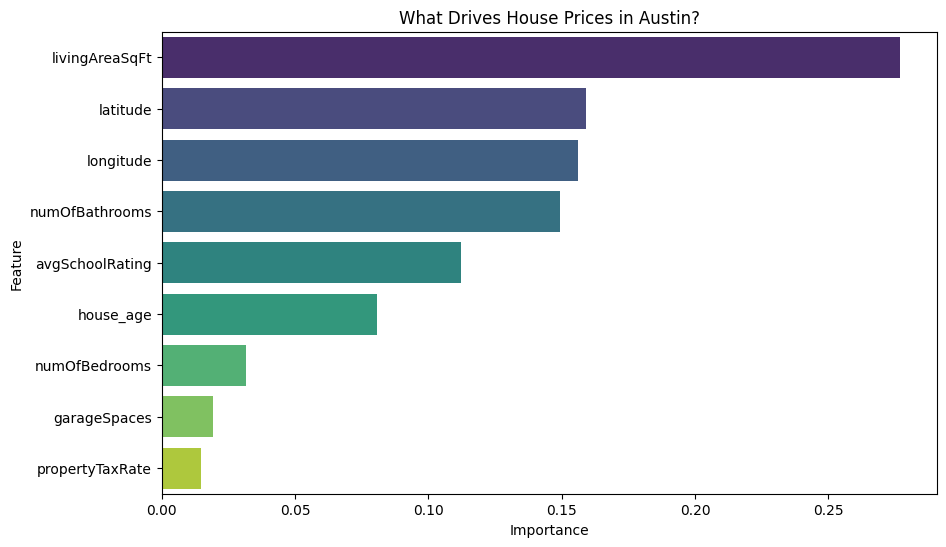

In [23]:
# Extract how much each feature contributed to the prediction
importances = adv_model.feature_importances_
feature_names = advanced_features
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Visualize it
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('What Drives House Prices in Austin?')
plt.show()

In [24]:
def predict_my_house(sqft, baths, beds, garage, school, age, lat, lon, tax):
    # Wrap inputs into a dataframe
    input_data = pd.DataFrame([[sqft, baths, beds, garage, school, age, lat, lon, tax]],
                              columns=advanced_features)

    # Predict (remember to reverse the Log transform!)
    log_pred = adv_model.predict(input_data)
    actual_pred = np.expm1(log_pred)

    return f"Estimated House Value: ${actual_pred[0]:,.2f}"

# Example: A 2500 sqft house, 3 bath, 4 bed, 2 car garage, 8/10 school, 10 years old, central Austin
print(predict_my_house(2500, 3, 4, 2, 8, 10, 30.26, -97.74, 1.98))

Estimated House Value: $994,585.26


In [25]:
import folium
from folium.plugins import HeatMap

# 1. Initialize a map centered on Austin
austin_map = folium.Map(location=[30.2672, -97.7431], zoom_start=11, tiles='CartoDB dark_matter')

# 2. Prepare the data: [Latitude, Longitude, Weight (Price)]
# We normalize the price to keep the heatmap from becoming just one giant blob
heat_data = [[row['latitude'], row['longitude'], row['latestPrice']] for index, row in df_clean.iterrows()]

# 3. Add the Heatmap layer
HeatMap(heat_data, radius=10, blur=15, max_zoom=1).add_to(austin_map)

# 4. Display the map
austin_map